In [3]:
import sys
from pathlib import Path

PROJECT_ROOT = Path().resolve().parent

sys.path.append(str(PROJECT_ROOT))

print(PROJECT_ROOT)

A:\AI Engineer in the way\ML Projects\Predictive-Maintenance-RUL


### Load Data

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

from src.data.loader import DataLoader
from src.data.validator import DataValidator

from src.config.config import (
    TRAIN_DATA_PATH,
    TEST_DATA_PATH,
    RUL_DATA_PATH
)

In [ ]:
loader = DataLoader(
    train_path=TRAIN_DATA_PATH,
    test_path=TEST_DATA_PATH,
    rul_path=RUL_DATA_PATH,
)

train_df = loader.load_train()
test_df = loader.load_test()
rul_df = loader.load_rul()

2026-07-18 16:19:09 | INFO | loader.py | Line:18 | Reading train_FD004.txt
2026-07-18 16:19:11 | INFO | loader.py | Line:21 | train_FD004.txt Loaded Successfully
2026-07-18 16:19:11 | INFO | loader.py | Line:18 | Reading test_FD004.txt
2026-07-18 16:19:12 | INFO | loader.py | Line:21 | test_FD004.txt Loaded Successfully
2026-07-18 16:19:12 | INFO | loader.py | Line:18 | Reading RUL_FD004.txt
2026-07-18 16:19:12 | INFO | loader.py | Line:21 | RUL_FD004.txt Loaded Successfully


### Vadlidate Data

In [ ]:
validator = DataValidator(
    train_df,
    test_df,
    rul_df,
)

report = validator.validate_all()

report

2026-07-18 16:19:37 | INFO | validator.py | Line:40 | Validating training dataset...
2026-07-18 16:19:37 | INFO | validator.py | Line:50 | Validating testing dataset...
2026-07-18 16:19:37 | INFO | validator.py | Line:60 | Validating RUL dataset...


{'train': {'valid': True, 'errors': [], 'warnings': []},
 'test': {'valid': True, 'errors': [], 'warnings': []},
 'rul': {'valid': True, 'errors': [], 'warnings': ['Duplicate rows found.']}}

### Dataset Shapes

In [ ]:
print("Train:", train_df.shape)
print("Test :", test_df.shape)
print("RUL  :", rul_df.shape)

Train: (61249, 26)
Test : (41214, 26)
RUL  : (248, 1)


In [ ]:
train_df.head()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
0,1,1,42.0049,0.8400,100.0,445.00,549.68,1343.43,1112.93,3.91,...,129.78,2387.99,8074.83,9.3335,0.02,330,2212,100.00,10.62,6.3670
1,1,2,20.0020,0.7002,100.0,491.19,606.07,1477.61,1237.50,9.35,...,312.59,2387.73,8046.13,9.1913,0.02,361,2324,100.00,24.37,14.6552
2,1,3,42.0038,0.8409,100.0,445.00,548.95,1343.12,1117.05,3.91,...,129.62,2387.97,8066.62,9.4007,0.02,329,2212,100.00,10.48,6.4213
3,1,4,42.0000,0.8400,100.0,445.00,548.70,1341.24,1118.03,3.91,...,129.80,2388.02,8076.05,9.3369,0.02,328,2212,100.00,10.54,6.4176
4,1,5,25.0063,0.6207,60.0,462.54,536.10,1255.23,1033.59,7.05,...,164.11,2028.08,7865.80,10.8366,0.02,305,1915,84.93,14.03,8.6754


In [ ]:
train_df.tail()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
61244,249,251,9.9998,0.2500,100.0,489.05,605.33,1516.36,1315.28,10.52,...,380.16,2388.73,8185.69,8.4541,0.03,372,2319,100.0,29.11,17.5234
61245,249,252,0.0028,0.0015,100.0,518.67,643.42,1598.92,1426.77,14.62,...,535.02,2388.46,8185.47,8.2221,0.03,396,2388,100.0,39.38,23.7151
61246,249,253,0.0029,0.0000,100.0,518.67,643.68,1607.72,1430.56,14.62,...,535.41,2388.48,8193.94,8.2525,0.03,395,2388,100.0,39.78,23.8270
61247,249,254,35.0046,0.8400,100.0,449.44,555.77,1381.29,1148.18,5.48,...,187.92,2388.83,8125.64,9.0515,0.02,337,2223,100.0,15.26,9.0774
61248,249,255,42.0030,0.8400,100.0,445.00,549.85,1369.75,1147.45,3.91,...,134.32,2388.66,8144.33,9.1207,0.02,333,2212,100.0,10.66,6.4341


In [ ]:
train_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61249 entries, 0 to 61248
Data columns (total 26 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   unit_number            61249 non-null  int64  
 1   time_in_cycles         61249 non-null  int64  
 2   operational_setting_1  61249 non-null  float64
 3   operational_setting_2  61249 non-null  float64
 4   operational_setting_3  61249 non-null  float64
 5   sensor_1               61249 non-null  float64
 6   sensor_2               61249 non-null  float64
 7   sensor_3               61249 non-null  float64
 8   sensor_4               61249 non-null  float64
 9   sensor_5               61249 non-null  float64
 10  sensor_6               61249 non-null  float64
 11  sensor_7               61249 non-null  float64
 12  sensor_8               61249 non-null  float64
 13  sensor_9               61249 non-null  float64
 14  sensor_10              61249 non-null  float64
 15  sensor_11    

In [ ]:
train_df.describe()

,unit_number,time_in_cycles,operational_setting_1,operational_setting_2,operational_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,...,sensor_12,sensor_13,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21
count,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,...,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000,61249.000000
mean,124.325181,134.311417,23.999823,0.571347,94.031576,472.882435,579.420056,1417.896600,1201.915359,8.031626,...,266.735665,2334.427590,8067.811812,9.285604,0.023252,347.760029,2228.613283,97.751396,20.864333,12.518995
std,71.995350,89.783389,14.780722,0.310703,14.251954,26.436832,37.342647,106.167598,119.327591,3.622872,...,138.479109,128.197859,85.670543,0.750374,0.004685,27.808283,145.472491,5.369424,9.936396,5.962697
min,1.000000,1.000000,0.000000,0.000000,60.000000,445.000000,535.480000,1242.670000,1024.420000,3.910000,...,128.310000,2027.570000,7845.780000,8.175700,0.020000,302.000000,1915.000000,84.930000,10.160000,6.084300
25%,60.000000,62.000000,10.004600,0.250700,100.000000,445.000000,549.330000,1350.550000,1119.490000,3.910000,...,134.520000,2387.910000,8062.630000,8.648000,0.020000,330.000000,2212.000000,100.000000,10.940000,6.566100
50%,126.000000,123.000000,25.001400,0.700000,100.000000,462.540000,555.740000,1367.680000,1136.920000,7.050000,...,183.450000,2388.060000,8083.810000,9.255600,0.020000,334.000000,2223.000000,100.000000,14.930000,8.960100
75%,185.000000,191.000000,41.998100,0.840000,100.000000,491.190000,607.070000,1497.420000,1302.620000,10.520000,...,371.400000,2388.170000,8128.350000,9.365800,0.030000,368.000000,2324.000000,100.000000,28.560000,17.135500
max,249.000000,543.000000,42.008000,0.842000,100.000000,518.670000,644.420000,1613.000000,1440.770000,14.620000,...,537.490000,2390.490000,8261.650000,11.066300,0.030000,399.000000,2388.000000,100.000000,39.890000,23.885200


### Number of Engines

In [ ]:
train_df["unit_number"].nunique()

249

### Number of Sensors

In [ ]:
sensor_columns = [
    col for col in train_df.columns
    if col.startswith("sensor")
]

len(sensor_columns)

21

## Operating Settings

In [ ]:
operating_columns = [
    c for c in train_df.columns
    if c.startswith("operational")
]

operating_columns

['operational_setting_1', 'operational_setting_2', 'operational_setting_3']

### Number of Records per Engine

In [ ]:
engine_cycles = (
    train_df
    .groupby("unit_number")
    .size()
)
engine_cycles.describe()

count    249.00000
mean     245.97992
std       73.11080
min      128.00000
25%      190.00000
50%      234.00000
75%      290.00000
max      543.00000
dtype: float64

- **Do engines live approximately the same amount?**
- No, it is vary alot and take right skewed data distribution.

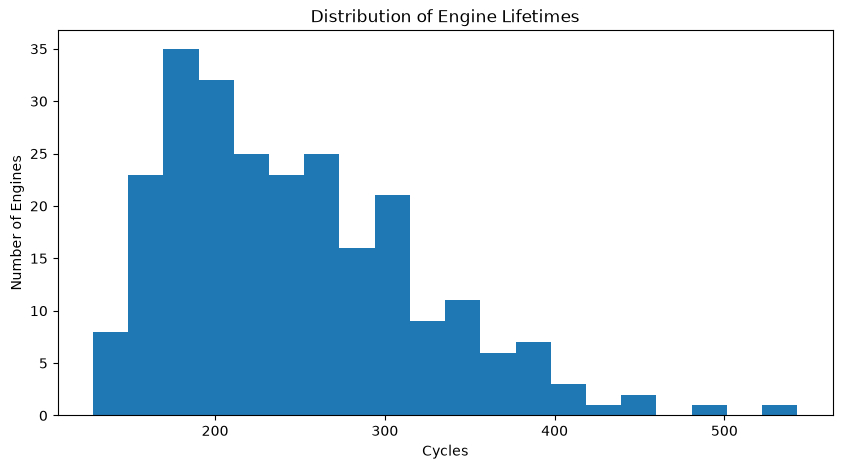

In [ ]:
plt.figure(figsize=(10,5))
plt.hist(engine_cycles, bins=20)
plt.xlabel("Cycles")
plt.ylabel("Number of Engines")
plt.title("Distribution of Engine Lifetimes")
plt.show()

In [ ]:
train_df.groupby("unit_number")["time_in_cycles"].max()

unit_number
1      321
2      299
3      307
4      274
5      193
      ... 
245    205
246    161
247    211
248    184
249    255
Name: time_in_cycles, Length: 249, dtype: int64

## Initial Findings

- The training dataset contains 249 engines.
- The testing dataset contains 248 engines.
- Each observation contains 21 sensor measurements.
- Three operational settings are recorded.
- The dataset contains no missing values.
- All variables are numeric.
- Engine lifetimes vary considerably.

# Engineering Decisions

### Decision 1

No preprocessing is required before continuing the analysis.

---

### Decision 2

Engine lifetime varies significantly.

Future models should account for variable sequence lengths.

---

### Decision 3

The next notebook will investigate sensor variability to determine whether some sensors contain little or no useful information.